In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:

df = pd.read_csv('House_Price.csv')
df['Area'] = df['Area'].replace({',': '', ' ': ''}, regex=True).astype(float)
df['Room'] = df['Room'].replace({',': '', ' ': ''}, regex=True).astype(float)
df['Parking'] = df['Parking'].replace({',': '', ' ': ''}, regex=True).astype(float)
df['Warehouse'] = df['Warehouse'].replace({',': '', ' ': ''}, regex=True).astype(float)
df['Elevator'] = df['Elevator'].replace({',': '', ' ': ''}, regex=True).astype(float)

df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,420.0,4.0,1.0,1.0,1.0,Zaferanieh,92400000000,3080000.00
1,420.0,5.0,1.0,1.0,0.0,Andisheh,11000000000,366666.00
2,415.0,5.0,1.0,1.0,1.0,Niavaran,53950000000,1798333.33
3,405.0,5.0,1.0,1.0,0.0,Andisheh,11000000000,366666.67
4,403.0,5.0,1.0,0.0,0.0,Andisheh,13000000000,433333.33


In [3]:
price_threshold = df['Price'].quantile(1)
df_cleaned = df[df['Price'] < price_threshold]
X = df_cleaned[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']]
y = df_cleaned['Price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=38)

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree=4)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred = poly_model.predict(X_test_poly)


In [5]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse:", mse, "\n", "r2:", r2 * 100, "%")


mse: 7.934002994473786e+18 
 r2: 82.570863494116 %


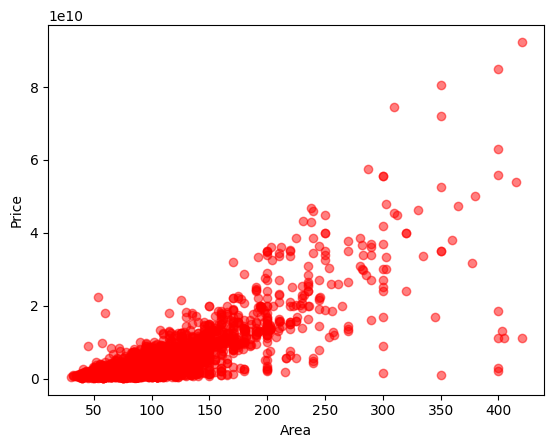

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(df.Area, df.Price,  color='red', alpha=0.5)



plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

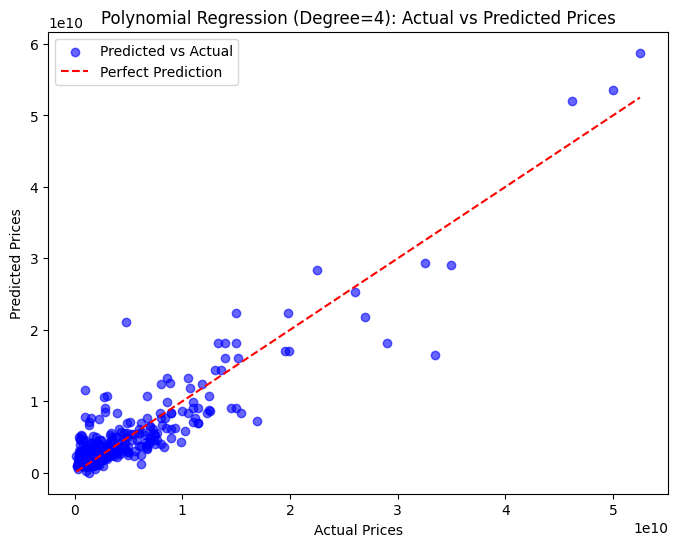

In [7]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--',
         label='Perfect Prediction')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Polynomial Regression (Degree=4): Actual vs Predicted Prices')
plt.legend()
plt.show()
